<a href="https://colab.research.google.com/" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week-1 Assignment

# Titanic: Survival Analysis

**Welcome to your first bonus assignment! The dataset you'll be working with is the legendary Titanic passenger dataset - one of the most famous datasets in data science.**

**The Titanic sank on April 15, 1912 after colliding with an iceberg. Of 2,224 passengers and crew aboard, only 710 survived. This dataset captures information about 891 of those passengers and your job is to explore it using Pandas and data visualization.**

**We have a set of questions for you that will build your understanding of data manipulation and visualization. GOOD LUCK!**

---

**Dataset columns:**
| Column | Description |
|--------|-------------|
| PassengerId | Unique ID for each passenger |
| Survived | 0 = Did not survive, 1 = Survived |
| Pclass | Ticket class (1 = 1st, 2 = 2nd, 3 = 3rd) |
| Name | Passenger name |
| Sex | Gender |
| Age | Age in years |
| SibSp | # of siblings/spouses aboard |
| Parch | # of parents/children aboard |
| Ticket | Ticket number |
| Fare | Passenger fare |
| Cabin | Cabin number |
| Embarked | Port of embarkation (C = Cherbourg, Q = Queenstown, S = Southampton) |

---

*Let's get started with importing numpy, pandas, seaborn and matplotlib!*

**Note** - matplotlib should be imported with the command:

`import matplotlib.pyplot as plt`

## Warm-Up Questions

These questions are **ungraded** and help you get comfortable with the dataset.

### 1) Import all important libraries
Import `numpy`, `pandas`, `seaborn`, and `matplotlib.pyplot`.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt



### 2) Read the CSV file and assign it to a variable
Load `W1_Titanic.csv` into a DataFrame.

In [2]:
df = pd.read_csv('W1_Titanic.csv')


### 3) Display the shape of the DataFrame
Expected Output: `(891, 12)`

In [3]:
print(df.shape)


(891, 12)


### 4) Print all column names of the DataFrame
Return an array/index containing the names of all columns.

In [4]:
print(df.columns.values)



<StringArray>
['PassengerId',    'Survived',      'Pclass',        'Name',         'Sex',
         'Age',       'SibSp',       'Parch',      'Ticket',        'Fare',
       'Cabin',    'Embarked']
Length: 12, dtype: str


### 5) Display the first 5 rows and the data types of each column
Use `.head()` and `.dtypes`.

In [5]:
print(df.head())
print(df.dtypes)


   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  
Pa

### 6) Check for missing values
Print the count of missing values in each column. 

*Hint: use `.isnull().sum()`*

In [6]:
print(df.isnull().sum())


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


### 7) Set `PassengerId` as the index of the DataFrame
Update the DataFrame in-place.

In [7]:
df = df.set_index('PassengerId')


### 8) Create a new column `FamilySize` = `SibSp` + `Parch` + 1
This represents the total number of family members aboard (including the passenger themselves).

In [9]:
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,FamilySize
PassengerId,,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,2
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,2
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,1
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,2
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,1
...,...,...,...,...,...,...,...,...,...,...,...,...
887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S,1
888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S,1
889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S,4



## GRADED Questions

### Answer these questions in the quiz. BEST OF LUCK!!

### 1. How many passengers survived?

In [10]:
import pandas as pd
df = pd.read_csv('W1_Titanic.csv')

print(df['Survived'].sum())


342


### 2. What is the average age of passengers who survived vs. those who did not?

*Hint: Use `groupby` on the `Survived` column, then take the mean of `Age`.*

*Note: Round your answer to 2 decimal places.*

In [11]:
import pandas as pd
df = pd.read_csv('W1_Titanic.csv')

print(df.groupby('Survived')['Age'].mean().round(2))


Survived
0    30.63
1    28.34
Name: Age, dtype: float64


### 3. What percentage (up to 2 decimal places) of female passengers survived?

In [12]:
import pandas as pd
df = pd.read_csv('W1_Titanic.csv')
females = df[df['Sex'] == 'female']
pct = (females['Survived'].sum() / len(females)) * 100
print(f"{pct:.2f}%")


74.20%


### 4. Which passenger class (Pclass) had the highest survival rate?

*Hint: Group by `Pclass` and find the mean of `Survived` for each class.*

In [13]:
import pandas as pd
df = pd.read_csv('W1_Titanic.csv')

survival_rate = df.groupby('Pclass')['Survived'].mean()
print(survival_rate)
print(f"Highest survival rate: Pclass {survival_rate.idxmax()}")


Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64
Highest survival rate: Pclass 1


### 5. What is the name of the passenger who paid the highest fare?

In [14]:
import pandas as pd
df = pd.read_csv('W1_Titanic.csv')

max_fare = df['Fare'].max()
print(df[df['Fare'] == max_fare]['Name'])

258                      Ward, Miss. Anna
679    Cardeza, Mr. Thomas Drake Martinez
737                Lesurer, Mr. Gustave J
Name: Name, dtype: str


### 6. Using seaborn, make the following plots, observe the trends, and answer the questions given in the form.

**Plot A** — Survival count by passenger class (bar plot)

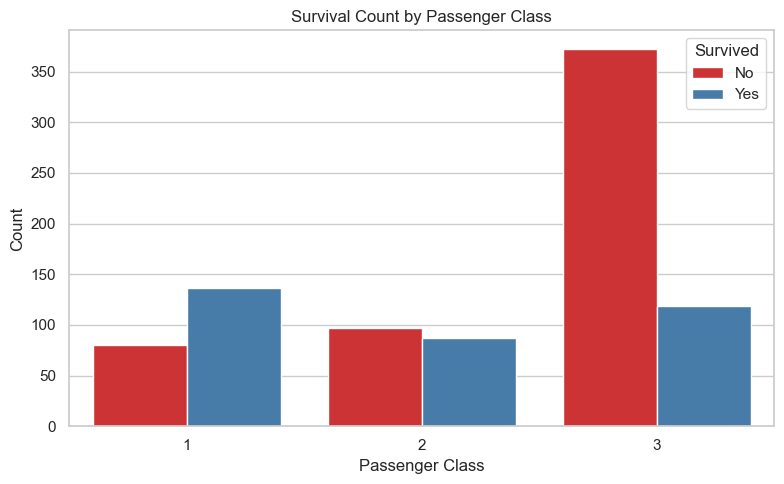

In [15]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('W1_Titanic.csv')


sns.set(style="whitegrid")

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Pclass', hue='Survived', palette='Set1')

plt.title('Survival Count by Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Count')
plt.legend(title='Survived', labels=['No', 'Yes'])
plt.tight_layout()
plt.show()

**Plot B** — Age distribution of survivors vs. non-survivors (histogram / KDE plot)

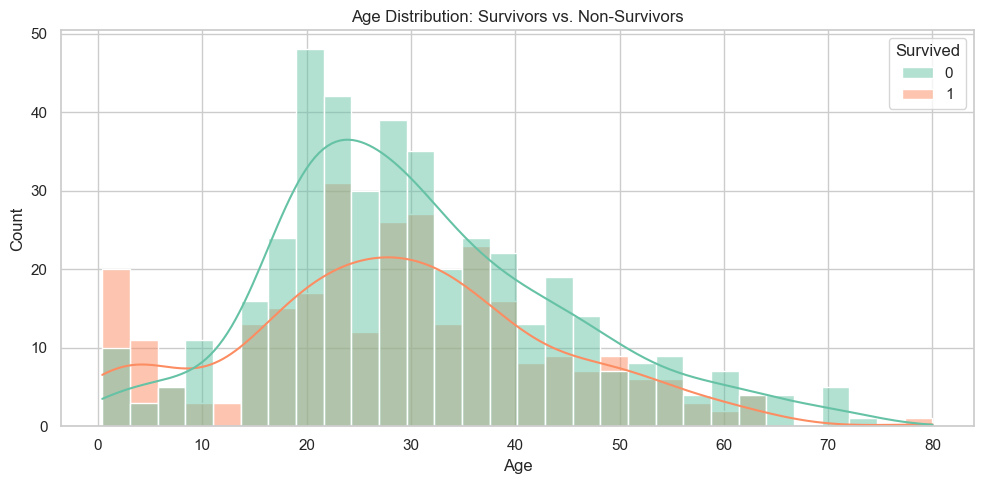

In [16]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('W1_Titanic.csv')

sns.set(style="whitegrid")

plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='Age', hue='Survived', kde=True, palette='Set2', bins=30)

plt.title('Age Distribution: Survivors vs. Non-Survivors')
plt.xlabel('Age')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

**Plot C** — Average fare by embarkation port (bar plot) — *Complete the missing line*

C:\Users\MEHUL RAJPAL\AppData\Local\Temp\ipykernel_31708\1234390558.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=avg_fare, x='Embarked', y='Fare', palette='muted')


<Figure size 800x500 with 0 Axes>

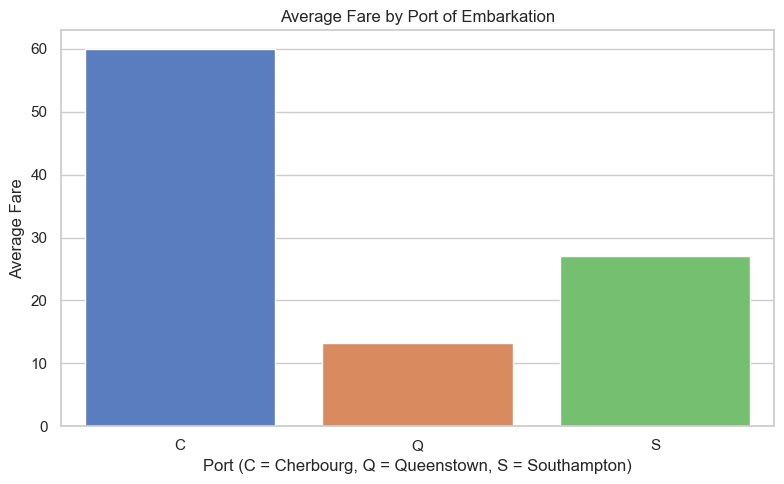

In [27]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('W1_Titanic.csv')



sns.set(style="whitegrid")

plt.figure(figsize=(8, 5))

avg_fare = df.groupby('Embarked', as_index=False)['Fare'].mean()

plt.figure(figsize=(8, 5))
sns.barplot(data=avg_fare, x='Embarked', y='Fare', palette='muted')

plt.title('Average Fare by Port of Embarkation')
plt.xlabel('Port (C = Cherbourg, Q = Queenstown, S = Southampton)')
plt.ylabel('Average Fare')
plt.tight_layout()
plt.show()





### 7. Among male passengers in 3rd class, how many survived?

In [28]:
import pandas as pd
df = pd.read_csv('W1_Titanic.csv')

male_3rd = df[(df['Sex'] == 'male') & (df['Pclass'] == 3)]
print(male_3rd['Survived'].sum())

47


### 8. How many passengers under the age of 10 were on board, and what fraction of them survived?

*Note: Ignore passengers with missing Age values. Round the fraction to 2 decimal places.*

In [29]:
import pandas as pd
df = pd.read_csv('W1_Titanic.csv')

under_10 = df[df['Age'] < 10].dropna(subset=['Age'])
count = len(under_10)
fraction = under_10['Survived'].mean()
print(f"Count: {count}")
print(f"Survival fraction: {fraction:.2f}")


Count: 62
Survival fraction: 0.61


---

## Bonus Questions

### These are UNGRADED and are given as an extra challenge.

---

### Which cabin deck (first letter of the Cabin column, e.g. 'C' for 'C85') had the highest survival rate?

*Hint: Extract the first character of the `Cabin` column after dropping rows where `Cabin` is null.*

In [21]:
cabin_df = df.dropna(subset=['Cabin']).copy()
cabin_df['Deck'] = cabin_df['Cabin'].str[0]
deck_survival = cabin_df.groupby('Deck')['Survived'].mean()
print(f"Highest survival deck: {deck_survival.idxmax()}")
print(deck_survival.sort_values(ascending=False))


Highest survival deck: D
Deck
D    0.757576
E    0.750000
B    0.744681
F    0.615385
C    0.593220
G    0.500000
A    0.466667
T    0.000000
Name: Survived, dtype: float64


### Extract titles from passenger names (e.g. 'Mr', 'Mrs', 'Miss') and find the most common title among survivors.

*Hint: The Name column looks like `Braund, Mr. Owen Harris` — extract the word between `, ` and `.`*

In [22]:
survivors = df[df['Survived'] == 1].copy()
survivors['Title'] = survivors['Name'].str.extract(r',\s*([^\.]+)\.')
print(survivors['Title'].value_counts().idxmax())
print(survivors['Title'].value_counts())



Miss
Title
Miss            127
Mrs              99
Mr               81
Master           23
Dr                3
Mlle              2
Mme               1
Ms                1
Major             1
Lady              1
Sir               1
Col               1
the Countess      1
Name: count, dtype: int64


### Plot a heatmap of the correlation matrix of all numeric columns.

*Use `seaborn.heatmap` with `annot=True`. Which two features are most positively correlated?*

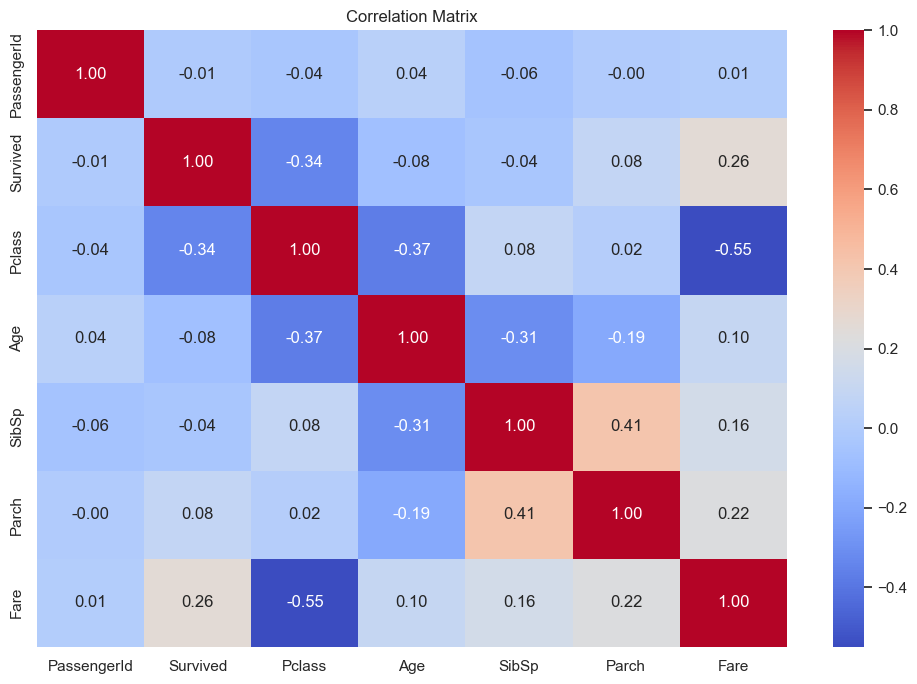

In [23]:
plt.figure(figsize=(10, 7))
sns.heatmap(df.select_dtypes(include='number').corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()


### Among passengers travelling alone (FamilySize == 1), what was the survival rate compared to those with family?

*You'll need to first create the `FamilySize` column (from the warm-up), then group.*

In [24]:
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df['IsAlone'] = (df['FamilySize'] == 1).astype(int)
print(df.groupby('IsAlone')['Survived'].mean().round(2))

IsAlone
0    0.51
1    0.30
Name: Survived, dtype: float64


### Which age group (bin them in 10-year intervals: 0-10, 10-20, 20-30, ...) had the lowest survival rate?

In [25]:
df['AgeGroup'] = pd.cut(df['Age'], bins=range(0, 91, 10), right=False,
                         labels=['0-10','10-20','20-30','30-40','40-50',
                                 '50-60','60-70','70-80','80-90'])
age_survival = df.groupby('AgeGroup', observed=True)['Survived'].mean().round(2)
print(age_survival)
print(f"Lowest survival age group: {age_survival.idxmin()}")

AgeGroup
0-10     0.61
10-20    0.40
20-30    0.35
30-40    0.44
40-50    0.38
50-60    0.42
60-70    0.32
70-80    0.00
80-90    1.00
Name: Survived, dtype: float64
Lowest survival age group: 70-80
